# Import Library

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import squarify
import matplotlib.cm as cm

# Pertanyaan Bisnis

- 1. Berapa tingkau daur ulang (Recycability Rate) untuk setiap kategori material
- 2. Berapa rasio sampah yang "Dapat Didaur Ulang" dibandingkan dengan yang "Tidak Dapat Didaur Ulang"?
- 3. Apa kategori dan jenis sampah yang menyumbang volume sampah non-recyclable terbesar secara global?
- 4. Bagaimana karakteristik material memengaruhi keberhasilan daur ulang?
- 5. Bagaimana pola fluktuasi tahunan rata-rata volume sampah plastik di pesisir pantai selama periode 2013–2021? Apakah volume sampah plastik di seluruh pantai terus meningkat dari tahun ke tahun?

# Data Wrangling 

## Gathering Data

In [2]:
# Membaca file csv
data_sampah = pd.read_csv('/Users/nurainaz/Documents/analisis data/capstone_project/MLW_Data.csv', encoding='ISO-8859-1')
info_sampah = pd.read_csv('/Users/nurainaz/Documents/analisis data/capstone_project/MLW_Meta.csv', encoding='ISO-8859-1')

In [3]:
# Menunjukkan 10 baris teratas dataset data_sampah
data_sampah.head(10)

,CommunityName,BeachName,BeachCountrycode,BeachRegionalSea,BeachLength_m,BeachLocation,BeachType,EventDate,EventType,NatRef,...,G202,G203,G204,G205,G206,G207,G208,G210,G211,G213
0,gBqsPxAZ,krapetz,BG,Black Sea,5850,Rural,Sandy,20160310,Cleanup,NaN,...,2.0,4.0,NaN,3.0,NaN,NaN,3.0,NaN,1.0,NaN
1,gBqsPxAZ,krapetz,BG,Black Sea,5850,Rural,Sandy,20150902,Cleanup,NaN,...,1.0,NaN,2.0,NaN,NaN,NaN,7.0,3.0,NaN,NaN
2,gBqsPxAZ,krapetz,BG,Black Sea,5850,Rural,Sandy,20151203,Cleanup,NaN,...,NaN,NaN,5.0,NaN,NaN,NaN,2.0,NaN,2.0,1.0
3,gBqsPxAZ,krapetz,BG,Black Sea,5850,Rural,Sandy,20151008,Cleanup,NaN,...,5.0,NaN,2.0,NaN,NaN,NaN,5.0,26.0,NaN,NaN
4,Legambiente Onlus,San Mauro Cilento (SA),IT,Unknown,100,NaN,NaN,20180428,Monitoring,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,2.0,NaN
5,Legambiente Onlus,"Spiaggia sul Lungomare Falcomat?, Reggio Calab...",IT,Mediterranean Sea,100,NaN,NaN,20160514,Cleanup,NaN,...,22.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
6,Surfrider Foundation Europe,"7 Place Salvador Allende, 94000 Cr?teil, France",NaN,Unknown,750,NaN,NaN,20190519,Cleanup,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,NaN,NaN,0.0
7,Swiss Litter Report,zürichsee_wollishofen_langendorfm,CH,NaN,50,Urban,Rocky,20170618,Cleanup,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN
8,HELMEPA - Hellenic Marine Environment Protecti...,"Agia Galini, Crete (port)",GR,Mediterranean Sea,84,Near river mouth,Rocky,20141005,Cleanup,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,10.0,NaN,NaN,NaN
9,Legambiente Onlus,"Spiaggia della Bandita, Palermo (PA)",IT,Mediterranean Sea,100,NaN,NaN,20140518,Cleanup,NaN,...,NaN,NaN,50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Menunjukkan 10 baris teratas dataset info_sampah
info_sampah.head(10)

,generalcode,category,generalname
0,G1,Plastic,"4/6-pack yokes, six-pack rings"
1,G3,Plastic,Shopping Bags incl. pieces
2,G4,Plastic,"Small plastic bags, e.g. freezer bags incl. pi..."
3,G5,Plastic,Plastic bags collective role; what remains fro...
4,G7,Plastic,Drink bottles <=0.5l
5,G8,Plastic,Drink bottles >0.5l
6,G9,Plastic,Cleaner bottles & containers
7,G10,Plastic,Food containers incl. fast food containers
8,G11,Plastic,Beach use related cosmetic bottles and contain...
9,G12,Plastic,Other cosmetics bottles & containers


## Assesing Data

### Data Sampah

In [5]:
# Menampilkan informasi dataset data_sampah
data_sampah.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3413 entries, 0 to 3412
Columns: 176 entries, CommunityName to G213
dtypes: float64(166), int64(2), object(8)
memory usage: 4.6+ MB


In [6]:
# Menampilkan statistika deskriptif dataset data_sampah
data_sampah.describe()

,BeachLength_m,EventDate,lon_x1,lat_y1,lon_x2,lat_y2,G1,G3,G4,G5,...,G202,G203,G204,G205,G206,G207,G208,G210,G211,G213
count,3.413000e+03,3.413000e+03,3413.000000,3413.000000,3413.000000,3413.000000,386.000000,2443.000000,1843.000000,403.000000,...,163.000000,804.000000,1244.000000,53.000000,124.000000,119.000000,2076.000000,983.000000,950.000000,1063.000000
mean,1.965880e+03,2.017084e+07,8.360550,44.045759,8.343571,44.047024,9.826425,35.025788,12.393380,11.483871,...,2.871166,0.868159,9.561897,1.169811,2.822581,2.941176,30.853083,8.617497,1.374737,13.343368
std,3.986795e+04,1.538090e+04,12.046756,10.613979,12.032500,10.615981,20.476998,240.932953,35.119834,21.139706,...,8.933325,2.869521,36.705348,0.545466,3.198192,3.237215,96.055165,98.166834,3.639526,281.412491
min,0.000000e+00,2.013031e+07,-149.551000,-36.538300,-149.550000,-36.538300,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.600000e+01,2.016081e+07,1.572860,42.450668,1.573860,42.455936,2.000000,1.000000,0.000000,1.000000,...,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
50%,9.900000e+01,2.017092e+07,8.519119,46.518221,8.519486,46.518221,5.000000,4.000000,2.000000,4.000000,...,1.000000,0.000000,1.000000,1.000000,1.000000,2.000000,4.000000,0.000000,0.000000,0.000000
75%,1.170000e+02,2.018043e+07,12.391820,47.503682,12.392820,47.504002,11.000000,18.000000,9.000000,11.000000,...,2.000000,1.000000,6.000000,1.000000,3.000000,3.000000,19.000000,1.000000,1.000000,0.000000
max,1.335049e+06,2.021013e+07,166.442000,73.661936,166.443000,73.661518,330.000000,9640.000000,600.000000,169.000000,...,101.000000,30.000000,584.000000,3.000000,15.000000,15.000000,1142.000000,2743.000000,64.000000,9000.000000


In [7]:
# Menghitung missing value dalam dataset data_sampah
data_sampah.isna().sum()

CommunityName          0
BeachName              0
BeachCountrycode     249
BeachRegionalSea    1113
BeachLength_m          0
                    ... 
G207                3294
G208                1337
G210                2430
G211                2463
G213                2350
Length: 176, dtype: int64

In [8]:
# Menghitung duplikat dalam dataset data_sampah 
data_sampah.duplicated().sum()

np.int64(12)

In [9]:
# Melihat nilai unik dalam fitur BeachCountrycode
data_sampah['BeachCountrycode'].unique()

array(['BG', 'IT', nan, 'CH', 'GR', 'FR', 'Int', 'GE', 'ES', 'DK', 'IE',
       'UK', 'BE', 'RO', 'UA', 'DE', 'NO', 'PT', 'TR', 'SI', 'DZ', 'CY',
       'FI', 'RU', 'NL', 'MA', 'HR', 'TN', 'SE', 'EL', 'CV', 'LB', 'IL',
       'MT', 'EE', 'ME', 'BA', 'ZA'], dtype=object)

### Info sampah

In [10]:
# Menampilkan informasi dataset info_sampah
info_sampah.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   generalcode  164 non-null    object
 1   category     164 non-null    object
 2   generalname  164 non-null    object
dtypes: object(3)
memory usage: 4.0+ KB


In [11]:
# Menampilkan statistika deskriptif dataset info_sampah

info_sampah.describe()

,generalcode,category,generalname
count,164,164,164
unique,164,9,164
top,G1,Plastic,"4/6-pack yokes, six-pack rings"
freq,1,89,1


In [12]:
# Menghitung missing value dalam dataset info_sampah
info_sampah.isna().sum()

generalcode    0
category       0
generalname    0
dtype: int64

In [13]:
# Menghitung banyak duplikat dalam dataset info_sampah
info_sampah.duplicated().sum()

np.int64(0)

In [14]:
# Melihat nilai unik dalam fitur category
info_sampah['category'].unique()

array(['Plastic', 'Rubber', 'Cloth/textile', 'Paper/Cardboard',
       'Processed/worked wood', 'Metal', 'Glass/ceramics', 'unidentified',
       'Chemicals'], dtype=object)

## Cleaning Data

### Data Sampah

In [15]:
# Mengubah tipe data fitur EventDate menjadi datetime
data_sampah['EventDate']=pd.to_datetime(data_sampah['EventDate'], format='%Y%m%d')

In [16]:
# Menunjukkan informasi dataset data_sampah
data_sampah.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3413 entries, 0 to 3412
Columns: 176 entries, CommunityName to G213
dtypes: datetime64[ns](1), float64(166), int64(1), object(8)
memory usage: 4.6+ MB


In [17]:
# Menghapus duplikat dalam dataset data_sampah
data_sampah = data_sampah.drop_duplicates()
print(f"Jumlah duplikat sekarang: {data_sampah.duplicated().sum()}")

Jumlah duplikat sekarang: 0


In [18]:
# Mengatasi missing value dengan melakukan imputasi
data_sampah['BeachCountrycode'] = data_sampah['BeachCountrycode'].fillna('unknown')

In [19]:
# Menghapus kolom NatRef dan BeachType pada dataset data_sampah
data_sampah = data_sampah.drop(columns=['NatRef', 'BeachType'])

In [20]:
# Melihat dimensi dataset data_sampah
print(data_sampah.shape)

(3401, 174)


In [21]:
data_sampah

,CommunityName,BeachName,BeachCountrycode,BeachRegionalSea,BeachLength_m,BeachLocation,EventDate,EventType,lon_x1,lat_y1,...,G202,G203,G204,G205,G206,G207,G208,G210,G211,G213
0,gBqsPxAZ,krapetz,BG,Black Sea,5850,Rural,2016-03-10,Cleanup,28.564998,43.695538,...,2.0,4.0,NaN,3.0,NaN,NaN,3.0,NaN,1.0,NaN
1,gBqsPxAZ,krapetz,BG,Black Sea,5850,Rural,2015-09-02,Cleanup,28.564998,43.695538,...,1.0,NaN,2.0,NaN,NaN,NaN,7.0,3.0,NaN,NaN
2,gBqsPxAZ,krapetz,BG,Black Sea,5850,Rural,2015-12-03,Cleanup,28.564998,43.695538,...,NaN,NaN,5.0,NaN,NaN,NaN,2.0,NaN,2.0,1.0
3,gBqsPxAZ,krapetz,BG,Black Sea,5850,Rural,2015-10-08,Cleanup,28.564998,43.695538,...,5.0,NaN,2.0,NaN,NaN,NaN,5.0,26.0,NaN,NaN
4,Legambiente Onlus,San Mauro Cilento (SA),IT,Unknown,100,NaN,2018-04-28,Monitoring,0.000135,0.000361,...,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,2.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3408,Legambiente Onlus,"Spiaggia di Marina di Montemarciano, Ancona (AN)",IT,Mediterranean Sea,100,NaN,2016-05-05,Monitoring,13.302130,43.671250,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
3409,Surfrider Foundation Europe,"La Lagune, 33260 La Teste de Buch, FRANCE",FR,North-east Atlantic Ocean,548,NaN,2018-06-02,Cleanup,-1.249080,44.548088,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
3410,Surfers Against Sewage,Bournemouth beach,UK,North-east Atlantic Ocean,2302,Urban,2015-03-28,Cleanup,-1.875802,50.715493,...,NaN,NaN,NaN,NaN,NaN,NaN,8.0,NaN,NaN,NaN
3411,ocean-R-evolution.com,cleanuptravels.com,CH,NaN,22,Rural,2017-03-15,Cleanup,9.291067,47.614022,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN


### Merge Data

In [22]:
sampah_copy=data_sampah.copy()

In [23]:
info_copy=info_sampah.copy()

In [24]:
identitas = ['CommunityName', 'BeachName', 'BeachCountrycode', 'EventDate', 'EventType']
kolom_sampah = [col for col in sampah_copy.columns if col.startswith('G') and col[1:].isdigit()]
df_long = sampah_copy.melt(
    id_vars=identitas,
    value_vars=kolom_sampah,
    var_name='generalcode',
    value_name='Jumlah_Sampah'
)

In [25]:
df_long['Jumlah_Sampah'] = pd.to_numeric(df_long['Jumlah_Sampah'], errors='coerce')
df_long = df_long[df_long['Jumlah_Sampah'] > 0]

In [26]:
df_long['generalcode'] = df_long['generalcode'].astype(str).str.strip()
info_copy['generalcode'] = info_copy['generalcode'].astype(str).str.strip()

In [27]:
df_final = pd.merge(df_long, info_copy, on='generalcode', how='left')
print(f"Jumlah baris NaN di kategori: {df_final['category'].isna().sum()}")
df_final

Jumlah baris NaN di kategori: 0


,CommunityName,BeachName,BeachCountrycode,EventDate,EventType,generalcode,Jumlah_Sampah,category,generalname
0,Monitoraggio Strategia Marina  Ministero dell...,Marina di Castagneto,IT,2017-10-25,Monitoring,G1,6.0,Plastic,"4/6-pack yokes, six-pack rings"
1,Monitoraggio Strategia Marina  Ministero dell...,Marina di Castagneto,IT,2017-03-10,Monitoring,G1,6.0,Plastic,"4/6-pack yokes, six-pack rings"
2,Monitoraggio Strategia Marina  Ministero dell...,Marina di Castagneto,IT,2018-11-22,Monitoring,G1,6.0,Plastic,"4/6-pack yokes, six-pack rings"
3,Monitoraggio Strategia Marina  Ministero dell...,Marina di Castagneto,IT,2018-04-12,Monitoring,G1,6.0,Plastic,"4/6-pack yokes, six-pack rings"
4,Monitoraggio Strategia Marina  Ministero dell...,Corigliano Foce Crati,IT,2017-10-31,Monitoring,G1,1.0,Plastic,"4/6-pack yokes, six-pack rings"
...,...,...,...,...,...,...,...,...,...
86926,Swiss Litter Report,zugersee_Immensee_Guedesd,CH,2017-06-30,Cleanup,G213,1.0,Chemicals,Paraffin/Wax
86927,Swiss Litter Report,arve_carouge_battistellak,CH,2017-04-17,Cleanup,G213,1.0,Chemicals,Paraffin/Wax
86928,Swiss Litter Report,arve_carouge_battistellak,CH,2018-03-18,Cleanup,G213,1.0,Chemicals,Paraffin/Wax
86929,gBqsPxAZ,"Plage de Pomegues (Marseille, France)",FR,2014-05-21,Cleanup,G213,2.0,Chemicals,Paraffin/Wax


In [28]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86931 entries, 0 to 86930
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CommunityName     86931 non-null  object        
 1   BeachName         86931 non-null  object        
 2   BeachCountrycode  86931 non-null  object        
 3   EventDate         86931 non-null  datetime64[ns]
 4   EventType         86931 non-null  object        
 5   generalcode       86931 non-null  object        
 6   Jumlah_Sampah     86931 non-null  float64       
 7   category          86931 non-null  object        
 8   generalname       86931 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(7)
memory usage: 6.0+ MB


In [29]:
df_final.isna().sum()

CommunityName       0
BeachName           0
BeachCountrycode    0
EventDate           0
EventType           0
generalcode         0
Jumlah_Sampah       0
category            0
generalname         0
dtype: int64

In [30]:
df_final.duplicated().sum()

np.int64(78)

In [31]:
df_final=df_final.drop_duplicates()

In [32]:
df_final.duplicated().sum()

np.int64(0)

In [33]:
df_final['generalname'].unique()

array(['4/6-pack yokes, six-pack rings ', 'Shopping Bags  incl. pieces',
       'Small plastic bags, e.g. freezer bags incl. pieces',
       'Plastic bags collective role; what remains from rip-off plastic bags',
       'Drink bottles  <=0.5l', 'Drink bottles  >0.5l',
       'Cleaner bottles & containers',
       'Food containers incl. fast food containers',
       'Beach use related cosmetic bottles and containers, eg. Sunblocks',
       'Other cosmetics bottles & containers',
       'Other bottles & containers (drums)',
       'Engine oil bottles & containers <50 cm',
       'Engine oil bottles & containers > 50 cm',
       'Jerry cans (square plastic containers with handle)',
       'Injection gun containers', 'Crates and containers / baskets',
       'Car parts', 'Plastic caps/lids drinks',
       'Plastic caps/lids chemicals, detergents (non-food)',
       'Plastic caps/lids unidentified',
       'Plastic rings from bottle caps/lids',
       'Tobacco pouches / plastic cigarette bo

In [34]:
df_final

,CommunityName,BeachName,BeachCountrycode,EventDate,EventType,generalcode,Jumlah_Sampah,category,generalname
0,Monitoraggio Strategia Marina  Ministero dell...,Marina di Castagneto,IT,2017-10-25,Monitoring,G1,6.0,Plastic,"4/6-pack yokes, six-pack rings"
1,Monitoraggio Strategia Marina  Ministero dell...,Marina di Castagneto,IT,2017-03-10,Monitoring,G1,6.0,Plastic,"4/6-pack yokes, six-pack rings"
2,Monitoraggio Strategia Marina  Ministero dell...,Marina di Castagneto,IT,2018-11-22,Monitoring,G1,6.0,Plastic,"4/6-pack yokes, six-pack rings"
3,Monitoraggio Strategia Marina  Ministero dell...,Marina di Castagneto,IT,2018-04-12,Monitoring,G1,6.0,Plastic,"4/6-pack yokes, six-pack rings"
4,Monitoraggio Strategia Marina  Ministero dell...,Corigliano Foce Crati,IT,2017-10-31,Monitoring,G1,1.0,Plastic,"4/6-pack yokes, six-pack rings"
...,...,...,...,...,...,...,...,...,...
86926,Swiss Litter Report,zugersee_Immensee_Guedesd,CH,2017-06-30,Cleanup,G213,1.0,Chemicals,Paraffin/Wax
86927,Swiss Litter Report,arve_carouge_battistellak,CH,2017-04-17,Cleanup,G213,1.0,Chemicals,Paraffin/Wax
86928,Swiss Litter Report,arve_carouge_battistellak,CH,2018-03-18,Cleanup,G213,1.0,Chemicals,Paraffin/Wax
86929,gBqsPxAZ,"Plage de Pomegues (Marseille, France)",FR,2014-05-21,Cleanup,G213,2.0,Chemicals,Paraffin/Wax


## Feature Engineering

In [37]:
#fitur Recyclability
def cek_recycle(generalname, category):
    generalname = str(generalname).lower()
    category = str(category).lower()
    sampah_no_daur_ulang = ['cigarette', 'diaper', 'nappies', 'sanitary', 'tampon', 'feces', 
                                   'medical', 'syringe', 'needle', 'condom', 'sponge', 'foam', 'tangled', 
                                   'shotgun', 'chemicals', 'unidentified', 'matches', 'brushes']
    if any(kata in generalname for kata in sampah_no_daur_ulang) or category in ['chemicals', 'unidentified']:
        return 'No'
    if category in ['metal', 'glass/ceramics', 'paper/cardboard']:
        return 'Yes'
    plastik_daur_ulang = ['bottle', 'container', 'cap', 'lid', 'crate', 'box', 'bucket', 'jar']
    if category == 'plastic' and any(kata in generalname for kata in plastik_daur_ulang):
        return 'Yes'
    wood_daur_ulang = ['timber', 'pallets', 'crates', 'wood']
    if category == 'processed/worked wood' and any(kata in generalname for kata in wood_daur_ulang):
        return 'Yes'
    return 'No'

In [38]:
df_final['Recyclability']=df_final.apply(lambda row: cek_recycle(row['generalname'], row['category']), axis=1)
print(df_final['Recyclability'].value_counts())

Recyclability
No     53554
Yes    33299
Name: count, dtype: int64


/var/folders/h8/2b8snf953zs4z5y4p8lyny5w0000gn/T/ipykernel_2625/1505258428.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['Recyclability']=df_final.apply(lambda row: cek_recycle(row['generalname'], row['category']), axis=1)


In [39]:
#fitur Hardness
def cek_hardness(nama_sampah, category):
    nama_sampah = str(nama_sampah).lower()
    category = str(category).lower()
    if category in ['metal', 'glass/ceramics', 'processed/worked wood']:
        return 'Hard'
    if category in ['cloth/textile', 'paper/cardboard', 'rubber']:
        return 'Flexible'
    barang_lunak = ['bag', 'wrapper', 'foil', 'rope', 'string', 'cloth', 'net', 'paper', 'flexible', 
                  'sack', 'sponge', 'line', 'band', 'sheeting', 'foam', 'balloon', 'condom', 'diaper', 'towel', 'mesh']
    
    barang_keras = ['bottle', 'can', 'glass', 'ceramic', 'wood', 'metal', 'cap', 'lid', 'hard', 
                  'box', 'ring', 'container', 'crate', 'pot', 'helmet', 'cartridge', 'cone', 'cd', 
                  'telephone', 'tube', 'bucket', 'lighter', 'pen', 'comb', 'toy', 'cutlery', 'tray', 'stick', 'pallet', 'jar']
    
    if any(kata in nama_sampah for kata in barang_keras):
        return 'Hard'
    if any(kata in nama_sampah for kata in barang_lunak):
        return 'Flexible'
    return 'unknown'

In [40]:
df_final['Hardness'] = df_final.apply(lambda row: cek_hardness(row['generalname'], row['category']), axis=1)
print(df_final['Hardness'].value_counts())

Hardness
Hard        45250
Flexible    26222
unknown     15381
Name: count, dtype: int64


/var/folders/h8/2b8snf953zs4z5y4p8lyny5w0000gn/T/ipykernel_2625/742465285.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['Hardness'] = df_final.apply(lambda row: cek_hardness(row['generalname'], row['category']), axis=1)


In [ ]:
#Fitur RecycleMethod
def cek_metode(kategori, recycle):
    if recycle=='No':
        return 'Not Recycled'
    
    kategori = str(kategori).lower()
    if kategori=='metal':
        return 'smelting and refining'
    elif kategori=='glass/ceramics':
        return 'crush and melting'
    elif kategori=='paper/cardboard':
        return 'pulping'
    elif kategori=='cloth/textile':
        return 'Textile Shredding/Repurposing'
    elif kategori == 'plastic':
        return 'melt and pelletized'
    elif kategori == 'processed/worked wood':
        return 'Reuse/Reprocessing'
    else:
        return 'unknown'

    

In [42]:
df_final['RecycleMethod']=df_final.apply(lambda row: cek_metode(row['category'], row['Recyclability']), axis=1)

/var/folders/h8/2b8snf953zs4z5y4p8lyny5w0000gn/T/ipykernel_2625/3102508592.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['RecycleMethod']=df_final.apply(lambda row: cek_metode(row['category'], row['Recyclability']), axis=1)


In [63]:
df_final['category'].unique()

array(['Plastic', 'Rubber', 'Cloth/textile', 'Paper/Cardboard',
       'Processed/worked wood', 'Metal', 'Glass/ceramics', 'unidentified',
       'Chemicals'], dtype=object)

In [64]:
print(df_final['category'].value_counts())

category
Plastic                  57911
Metal                     8286
Glass/ceramics            5093
Paper/Cardboard           4684
Cloth/textile             3805
Processed/worked wood     3500
Rubber                    3006
unidentified               425
Chemicals                  143
Name: count, dtype: int64


In [43]:
df_final

,CommunityName,BeachName,BeachCountrycode,EventDate,EventType,generalcode,Jumlah_Sampah,category,generalname,Recyclability,Hardness,RecycleMethod
0,Monitoraggio Strategia Marina  Ministero dell...,Marina di Castagneto,IT,2017-10-25,Monitoring,G1,6.0,Plastic,"4/6-pack yokes, six-pack rings",No,Hard,Not Recycled
1,Monitoraggio Strategia Marina  Ministero dell...,Marina di Castagneto,IT,2017-03-10,Monitoring,G1,6.0,Plastic,"4/6-pack yokes, six-pack rings",No,Hard,Not Recycled
2,Monitoraggio Strategia Marina  Ministero dell...,Marina di Castagneto,IT,2018-11-22,Monitoring,G1,6.0,Plastic,"4/6-pack yokes, six-pack rings",No,Hard,Not Recycled
3,Monitoraggio Strategia Marina  Ministero dell...,Marina di Castagneto,IT,2018-04-12,Monitoring,G1,6.0,Plastic,"4/6-pack yokes, six-pack rings",No,Hard,Not Recycled
4,Monitoraggio Strategia Marina  Ministero dell...,Corigliano Foce Crati,IT,2017-10-31,Monitoring,G1,1.0,Plastic,"4/6-pack yokes, six-pack rings",No,Hard,Not Recycled
...,...,...,...,...,...,...,...,...,...,...,...,...
86926,Swiss Litter Report,zugersee_Immensee_Guedesd,CH,2017-06-30,Cleanup,G213,1.0,Chemicals,Paraffin/Wax,No,unknown,Not Recycled
86927,Swiss Litter Report,arve_carouge_battistellak,CH,2017-04-17,Cleanup,G213,1.0,Chemicals,Paraffin/Wax,No,unknown,Not Recycled
86928,Swiss Litter Report,arve_carouge_battistellak,CH,2018-03-18,Cleanup,G213,1.0,Chemicals,Paraffin/Wax,No,unknown,Not Recycled
86929,gBqsPxAZ,"Plage de Pomegues (Marseille, France)",FR,2014-05-21,Cleanup,G213,2.0,Chemicals,Paraffin/Wax,No,unknown,Not Recycled


In [44]:
# Menyimpan df_final ke file Data_Sampah.csv
df_final.to_csv('Data_Sampah.csv', index=False)

# EDA

In [45]:
df_final['Jumlah_Sampah'].describe()

count    86853.000000
mean        23.865359
std        161.030149
min          1.000000
25%          1.000000
50%          3.000000
75%         10.000000
max      10551.000000
Name: Jumlah_Sampah, dtype: float64

In [46]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 86853 entries, 0 to 86930
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CommunityName     86853 non-null  object        
 1   BeachName         86853 non-null  object        
 2   BeachCountrycode  86853 non-null  object        
 3   EventDate         86853 non-null  datetime64[ns]
 4   EventType         86853 non-null  object        
 5   generalcode       86853 non-null  object        
 6   Jumlah_Sampah     86853 non-null  float64       
 7   category          86853 non-null  object        
 8   generalname       86853 non-null  object        
 9   Recyclability     86853 non-null  object        
 10  Hardness          86853 non-null  object        
 11  RecycleMethod     86853 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(10)
memory usage: 8.6+ MB


In [47]:
#KPI DATA
total_sampah = df_final['Jumlah_Sampah'].sum()
print(f'Total Sampah: {total_sampah} unit')

#Persentase data yang dapat direcycle
total_recyclable = df_final[df_final['Recyclability'] == 'Yes']['Jumlah_Sampah'].sum()
kpi_recyclability_rate = (total_recyclable / total_sampah) * 100
print(f"Global Recyclability Rate: {kpi_recyclability_rate:.1f}%")

#Sampah yang sering muncul
top_item_vol = df_final.groupby('generalname')['Jumlah_Sampah'].sum().max()
top_item_name = df_final.groupby('generalname')['Jumlah_Sampah'].sum().idxmax()
kpi_top_pollutant_dom = (top_item_vol / total_sampah) * 100
print(f"Top Item Dominance: {kpi_top_pollutant_dom:.1f}% (Didominasi oleh: {top_item_name})")

Total Sampah: 2072778.0 unit
Global Recyclability Rate: 24.2%
Top Item Dominance: 24.3% (Didominasi oleh: Cigarette butts and filters)


In [48]:
# Mengelompokkan jumlah sampah dan recyclability berdasarkan kategori sampah
analisis_kategori = df_final.groupby(['category', 'Recyclability']).agg({
    'Jumlah_Sampah': sum,
    'generalname': 'count'
}).reset_index()
print(analisis_kategori)
pivot1 = df_final.pivot_table(
    index = 'category',
    columns = 'Recyclability',
    values='Jumlah_Sampah',
    aggfunc='sum',
    fill_value = 0
)
pivot1['TotalSampah']=pivot1.sum(axis=1)
if 'Yes' in pivot1.columns:
    pivot1['%Recyclability'] = (pivot1['Yes'] / pivot1['TotalSampah']) * 100
else:
    pivot1['%Recyclability'] = 0

# Mengurutkan berdasarkan Total Sampah per Kategori Tertinggi
pivot1=pivot1.sort_values(by='TotalSampah', ascending=False)
print(pivot1[['TotalSampah', '%Recyclability']].round(2))

                 category Recyclability  Jumlah_Sampah  generalname
0               Chemicals            No        14184.0          143
1           Cloth/textile            No        30059.0         3805
2          Glass/ceramics           Yes       112491.0         5093
3                   Metal           Yes        82389.0         8286
4         Paper/Cardboard            No         6189.0          733
5         Paper/Cardboard           Yes        36635.0         3951
6                 Plastic            No      1501111.0        43904
7                 Plastic           Yes       257042.0        14007
8   Processed/worked wood            No         6064.0         1538
9   Processed/worked wood           Yes        12829.0         1962
10                 Rubber            No        12480.0         3006
11           unidentified            No         1305.0          425
Recyclability          TotalSampah  %Recyclability
category                                          
Plastic       

/var/folders/h8/2b8snf953zs4z5y4p8lyny5w0000gn/T/ipykernel_2625/204344989.py:2: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  analisis_kategori = df_final.groupby(['category', 'Recyclability']).agg({


In [49]:
#  Kategori Non-Recyclable Terbesar
# ---------------------------------------------------------
print("\nKategori Penyumbang Sampah Non-Recyclable Terbesar")
if 'No' in pivot1.columns:
    top_non_recyclable = pivot1[['No']].sort_values(by='No', ascending=False)
    print(top_non_recyclable.head())
else:
    print("Tidak ada data 'No' pada kolom Recyclability.")




Kategori Penyumbang Sampah Non-Recyclable Terbesar
Recyclability           No
category                  
Plastic          1501111.0
Cloth/textile      30059.0
Chemicals          14184.0
Rubber             12480.0
Paper/Cardboard     6189.0


In [50]:
non_recyclable_df = df_final[df_final['Recyclability'] == 'No'].copy()

# 1. Analisis Kategori penyumbang Non-Recyclable terbesar
kategori_non_recycle = non_recyclable_df.groupby('category')['Jumlah_Sampah'].sum().reset_index()
kategori_non_recycle = kategori_non_recycle.sort_values(by='Jumlah_Sampah', ascending=False)
print("--- Top Kategori Non-Recyclable ---")
print(kategori_non_recycle.head())

# 2. Detail 10 Barang spesifik (generalname) penyumbang Non-Recyclable
top_barang_non_recycle = non_recyclable_df.groupby('generalname')['Jumlah_Sampah'].sum().reset_index()
top_barang_non_recycle = top_barang_non_recycle.sort_values(by='Jumlah_Sampah', ascending=False).head(10)
print("\n--- Top 10 Barang Spesifik (Generalname) Non-Recyclable ---")
print(top_barang_non_recycle)

--- Top Kategori Non-Recyclable ---
          category  Jumlah_Sampah
3          Plastic      1501111.0
1    Cloth/textile        30059.0
0        Chemicals        14184.0
5           Rubber        12480.0
2  Paper/Cardboard         6189.0

--- Top 10 Barang Spesifik (Generalname) Non-Recyclable ---
                                   generalname  Jumlah_Sampah
10                 Cigarette butts and filters       503329.0
60                Plastic pieces 2.5 > < 50 cm       197556.0
65         Polystyrene pieces 2.5 cm > < 50 cm       107246.0
78                 Shopping Bags  incl. pieces        84961.0
17                           Cotton bud sticks        71618.0
20              Crisps packets/sweets wrappers        69925.0
83    String and cord (diameter less than 1cm)        58660.0
82                         Straws and stirrers        39385.0
63  Plastic/polystyrene pieces 2.5 cm > < 50cm        31601.0
39                                Lolly sticks        27518.0


In [51]:
# Rasio Dapat Didaur Ulang vs Tidak
print("\nRasio Sampah Recyclable vs Non-Recyclable (Total Volume)")
rasio_recyclable = df_final.groupby('Recyclability')['Jumlah_Sampah'].sum()
persentase_rasio = (rasio_recyclable / rasio_recyclable.sum()) * 100
print(persentase_rasio.round(2).astype(str) + '%')


Rasio Sampah Recyclable vs Non-Recyclable (Total Volume)
Recyclability
No     75.81%
Yes    24.19%
Name: Jumlah_Sampah, dtype: object


In [52]:
# Pengaruh Hardness terhadap Recyclability
print("\nPengaruh Hardness terhadap Probabilitas Daur Ulang")
hardness_analysis = df_final.pivot_table(
    index='Hardness', 
    columns='Recyclability', 
    values='Jumlah_Sampah', 
    aggfunc='sum', 
    fill_value=0
)
hardness_analysis['Total'] = hardness_analysis.sum(axis=1)

if 'Yes' in hardness_analysis.columns:
    hardness_analysis['Probabilitas_Bisa_Didaur_Ulang(%)'] = (hardness_analysis['Yes'] / hardness_analysis['Total']) * 100
else:
    hardness_analysis['Probabilitas_Bisa_Didaur_Ulang(%)'] = 0

print(hardness_analysis[['Total', 'Probabilitas_Bisa_Didaur_Ulang(%)']].round(2))


Pengaruh Hardness terhadap Probabilitas Daur Ulang
Recyclability     Total  Probabilitas_Bisa_Didaur_Ulang(%)
Hardness                                                  
Flexible       378508.0                               9.68
Hard           722776.0                              64.30
unknown        971494.0                               0.00


In [53]:
# Membuat tabel Crosstab dasar dengan total baris/kolom
asosiasi_kategori_daur_ulang = pd.crosstab(
    index=df_final['Hardness'], 
    columns=df_final['Recyclability'],
    margins=True,          
    margins_name='Total'   # Memberi nama pada kolom/baris total
)

# Menampilkan hasil
print("Tabel Frekuensi Kekerasan vs Kemampuan Daur Ulang:")
display(asosiasi_kategori_daur_ulang) 

Tabel Frekuensi Kekerasan vs Kemampuan Daur Ulang:


Recyclability,No,Yes,Total
Hardness,,,
Flexible,22271,3951,26222
Hard,15902,29348,45250
unknown,15381,0,15381
Total,53554,33299,86853


In [54]:
#Korelasi Hardness dengan Recyclability
from scipy.stats import chi2_contingency
#Cramer V Hardness dan Recyclability
asosiasi = asosiasi_kategori_daur_ulang.iloc[:-1, :-1]
chi2, p_value, dof, expected = chi2_contingency(asosiasi)
n = asosiasi.sum().sum() 
r, k = asosiasi.shape    

# Menghitung nilai Cramer's V sesuai rumus
cramers_v = np.sqrt(chi2 / (n * min(k-1, r-1)))
print(f"Cramer's V    : {cramers_v:.4f}")

Cramer's V    : 0.5781


In [55]:
# Menghitung Kuartil 1 (Q1) dan Kuartil 3 (Q3)
Q1 = df_final['Jumlah_Sampah'].quantile(0.25)
Q3 = df_final['Jumlah_Sampah'].quantile(0.75)

# Menghitung rentang IQR
IQR = Q3 - Q1

# Menentukan batas bawah dan batas atas
batas_bawah = Q1 - (1.5 * IQR)
batas_atas = Q3 + (1.5 * IQR)

# Menyaring data yang tergolong anomali (outliers)
outliers_sampah = df_final[(df_final['Jumlah_Sampah'] < batas_bawah) | (df_final['Jumlah_Sampah'] > batas_atas)]

# Menampilkan hasil
print(f"Batas Bawah: {batas_bawah}")
print(f"Batas Atas: {batas_atas}")
print(f"Total baris anomali ditemukan: {len(outliers_sampah)}")

# Melihat 5 data anomali teratas
outliers_sampah.sort_values(by='Jumlah_Sampah', ascending=False).head()

Batas Bawah: -12.5
Batas Atas: 23.5
Total baris anomali ditemukan: 11956


,CommunityName,BeachName,BeachCountrycode,EventDate,EventType,generalcode,Jumlah_Sampah,category,generalname,Recyclability,Hardness,RecycleMethod
18908,Hold Danmark Rent,Amager Strandpark,DK,2014-06-19,Cleanup,G27,10551.0,Plastic,Cigarette butts and filters,No,unknown,Not Recycled
1821,Surfrider Foundation Europe,"3 Boulevard Clemenceau, 76600 Le Havre, France",FR,2019-05-18,Cleanup,G3,9640.0,Plastic,Shopping Bags incl. pieces,No,Flexible,Not Recycled
86834,"Aarhus University, Denmark","MSFD Pomlenakke, Falster",DK,2016-04-23,Monitoring,G213,9000.0,Chemicals,Paraffin/Wax,No,unknown,Not Recycled
46390,Surfrider Foundation Europe,"3 Boulevard Clemenceau, 76600 Le Havre, France",FR,2019-05-18,Cleanup,G79,7730.0,Plastic,Plastic pieces 2.5 > < 50 cm,No,unknown,Not Recycled
19597,Surfrider Foundation Europe,"31 Quai de la Loire, 75019 Paris, France",unknown,2019-05-23,Cleanup,G27,7500.0,Plastic,Cigarette butts and filters,No,unknown,Not Recycled


# Visualisasi Data dan Explanatary Data

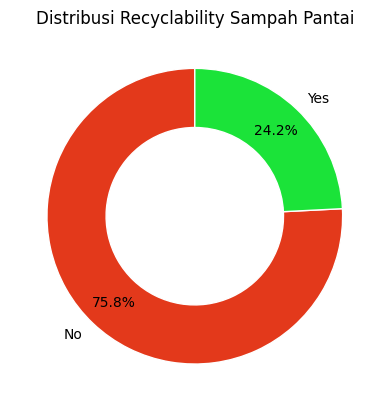

In [56]:
# 1. VISUALISASI PIE CHART: Rasio Recyclable vs Non-Recyclable

plt.figure()
plt.pie(
    rasio_recyclable,
    labels=rasio_recyclable.index,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.8,
    colors=['#E3391B', '#1BE339'],
    wedgeprops={
        'width': 0.4,
        'edgecolor': 'white'
    }
)

plt.title('Distribusi Recyclability Sampah Pantai')
plt.show()

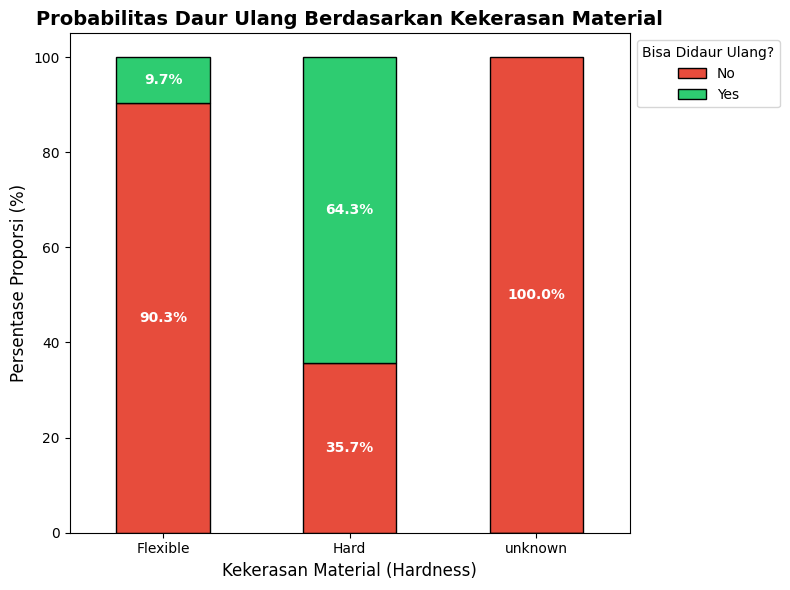

In [57]:
# 2.  VISUALISASI BAR CHART: Pengaruh Karakteristik Material terhadap Recyclability

cols = []
if 'No' in hardness_analysis.columns: cols.append('No')
if 'Yes' in hardness_analysis.columns: cols.append('Yes')
hardness_analysis = hardness_analysis[cols]
hardness_pct = hardness_analysis.div(hardness_analysis.sum(axis=1), axis=0)*100
fig, ax2 = plt.subplots(figsize=(8, 6))
warna_chart = ['#e74c3c', '#2ecc71'] if len(cols) == 2 else ['#3498db']
hardness_pct.plot(kind='bar', stacked=True, color=warna_chart, ax=ax2, edgecolor='black', linewidth=1)

ax2.set_title('Probabilitas Daur Ulang Berdasarkan Kekerasan Material', fontsize=14, fontweight='bold')
ax2.set_xlabel('Kekerasan Material (Hardness)', fontsize=12)
ax2.set_ylabel('Persentase Proporsi (%)', fontsize=12)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.legend(title='Bisa Didaur Ulang?', labels=cols, loc='upper left', bbox_to_anchor=(1, 1))

for p in ax2.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 5: # Hanya tampilkan teks jika proporsinya lebih dari 5% agar tidak menumpuk
        ax2.text(x + width/2, 
                 y + height/2, 
                 f'{height:.1f}%', 
                 horizontalalignment='center', 
                 verticalalignment='center',
                 color='white', fontweight='bold')

plt.tight_layout()
plt.show()

In [58]:
# 3.  VISUALISASI TREEMAP: TOP 15 BARANG NON-RECYCLABLE

df_treemap = non_recyclable_df.groupby(['category', 'generalname'])['Jumlah_Sampah'].sum().reset_index()

df_treemap = df_treemap[df_treemap['Jumlah_Sampah'] > 0]

fig = px.treemap(
    df_treemap.sort_values(by='Jumlah_Sampah', ascending=False).head(15), 
    path=[px.Constant("Total Non-Recyclable Waste"), 'category', 'generalname'], 
    values='Jumlah_Sampah',
    color='category', 
    color_discrete_sequence=px.colors.qualitative.Pastel, 
    title='<b>Treemap: Penyumbang Terbesar Sampah Non-Recyclable</b><br><sup>Hierarki: Kategori -> Jenis Barang</sup>'
)

# Mempercantik tampilan teks di dalam kotak
fig.update_traces(
    textinfo="label+value+percent parent",
    hovertemplate='<b>%{label}</b><br>Volume: %{value}<br>Persentase di Kategori Ini: %{percentParent:.1%}'
)

fig.update_layout(
    margin=dict(t=50, l=25, r=25, b=25),
    font=dict(size=12)
)

fig.show(renderer="browser")

/var/folders/h8/2b8snf953zs4z5y4p8lyny5w0000gn/T/ipykernel_2625/1931931563.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(kategori_unik))


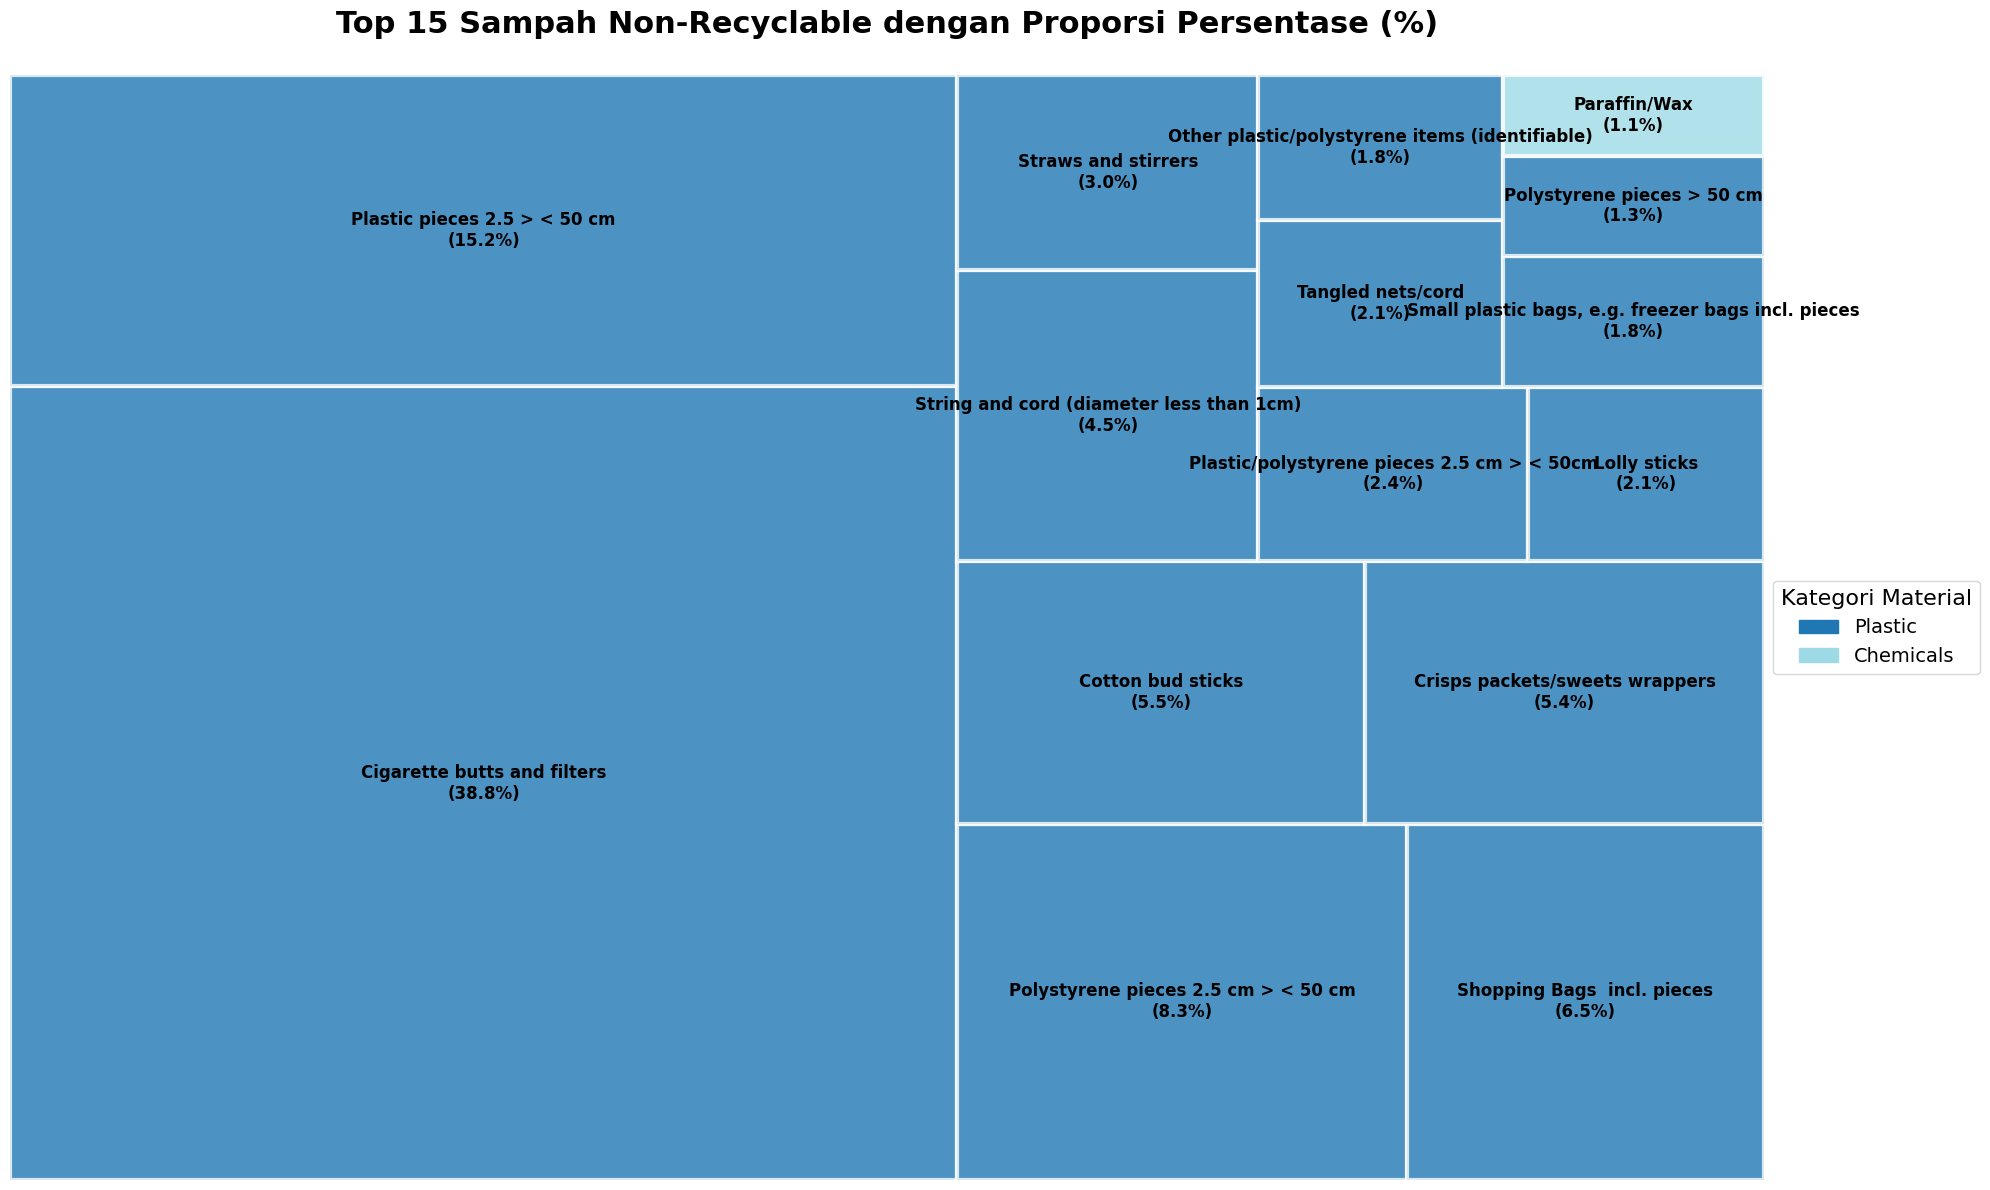

In [59]:

# 2. Grouping dan Ambil Top 15
df_tree_pct = non_recyclable_df.groupby(['category', 'generalname'])['Jumlah_Sampah'].sum().reset_index()
df_tree_pct = df_tree_pct.sort_values(by='Jumlah_Sampah', ascending=False).head(15)

# 3. Hitung Total Volume dari Top 15
total_top15 = df_tree_pct['Jumlah_Sampah'].sum()

# 4. Membuat Label Gabungan: "Nama Barang \n (Persentase%)"
labels = df_tree_pct.apply(
    lambda row: f"{row['generalname']}\n({((row['Jumlah_Sampah'] / total_top15) * 100):.1f}%)", 
    axis=1
)

# 5. Mapping Warna per Kategori 
kategori_unik = df_tree_pct['category'].unique()
cmap = cm.get_cmap('tab20', len(kategori_unik)) 
warna_dict = {kat: cmap(i) for i, kat in enumerate(kategori_unik)}
colors = df_tree_pct['category'].map(warna_dict)

# 6. Visualisasi (UKURAN DIPERBESAR)
# figsize=(20, 12) akan membuat kanvas jauh lebih lebar dan tinggi
plt.figure(figsize=(20, 12)) 

squarify.plot(
    sizes=df_tree_pct['Jumlah_Sampah'], 
    label=labels, 
    color=colors, 
    alpha=0.8,
    edgecolor='white',
    linewidth=3,
    text_kwargs={'fontsize': 12, 'weight': 'bold', 'color': 'black'})

# Ukuran font judul dinaikkan menjadi 22
plt.title('Top 15 Sampah Non-Recyclable dengan Proporsi Persentase (%)', fontsize=22, fontweight='bold', pad=30)
plt.axis('off')

# Menambahkan Legend Kategori (Ukuran font legend juga diperbesar)
import matplotlib.patches as mpatches
legend_handles = [mpatches.Patch(color=warna_dict[kat], label=kat) for kat in kategori_unik]
plt.legend(
    handles=legend_handles, 
    title="Kategori Material", 
    title_fontsize=16, 
    fontsize=14, 
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.show()

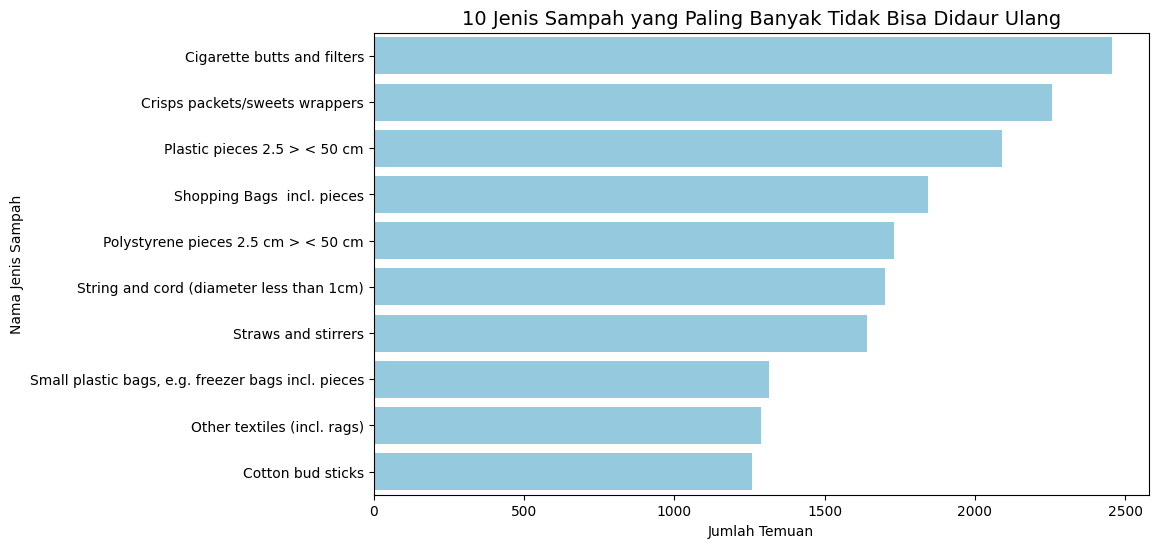

In [60]:
# BARCHART: TOP 10 Jenis Sampah Non-Recyclable
plt.figure(figsize=(10, 6))
non_recyc = df_final[df_final['Recyclability'] == 'No']['generalname'].value_counts().nlargest(10)

sns.barplot(x=non_recyc.values, y=non_recyc.index, color="skyblue")
plt.title('10 Jenis Sampah yang Paling Banyak Tidak Bisa Didaur Ulang', fontsize=14)
plt.xlabel('Jumlah Temuan')
plt.ylabel('Nama Jenis Sampah')
plt.show()

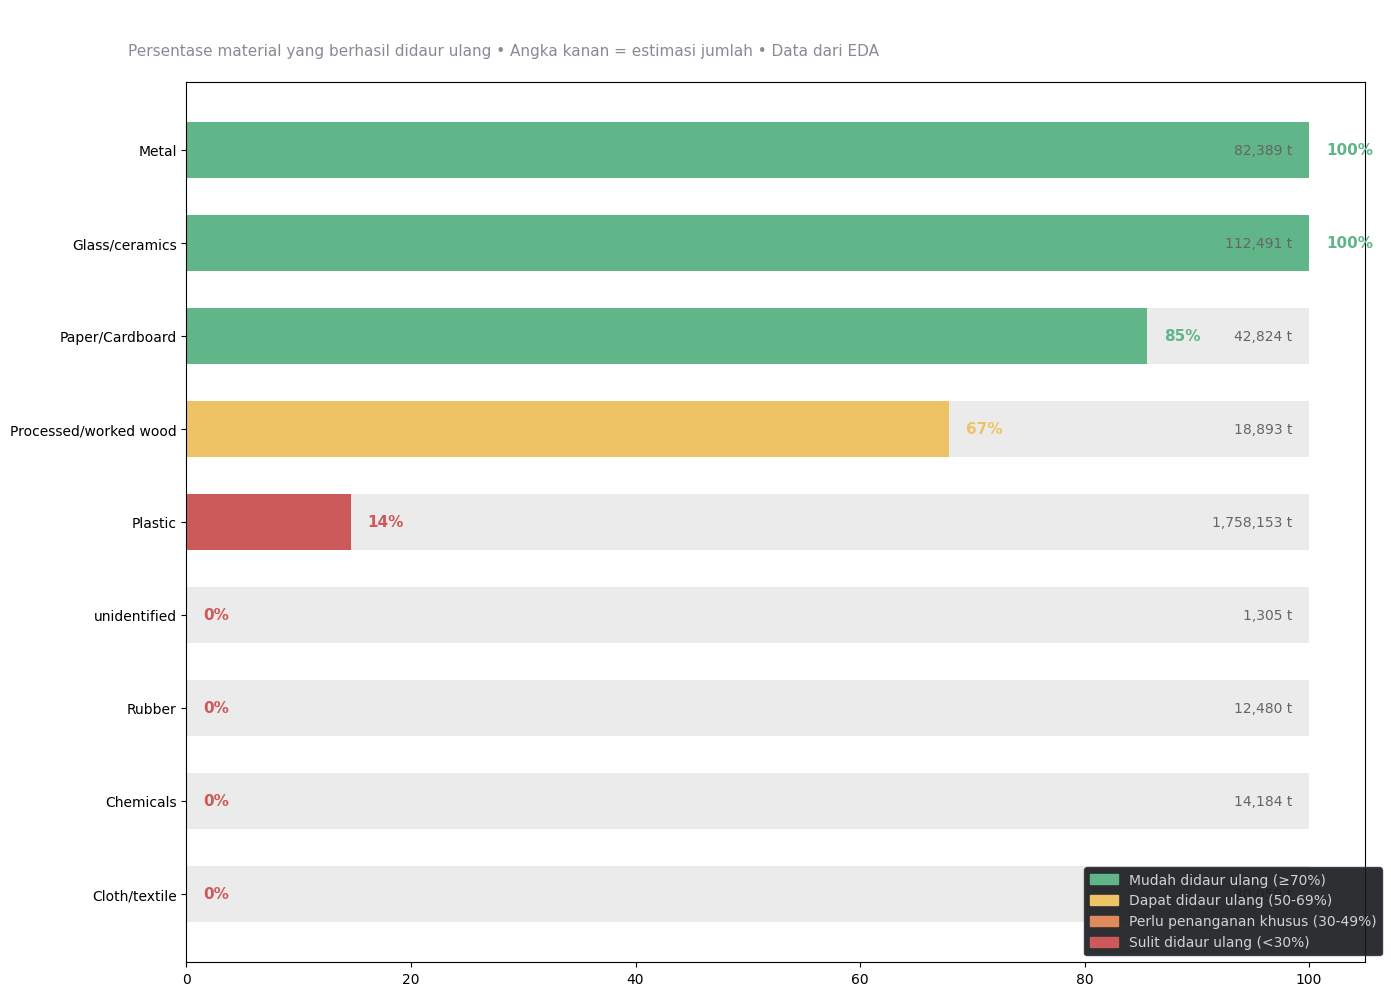

In [61]:
#4. BAR CHART: Recyclability Rate setiap kategori
'''
Mempersiapkan data
'''
pivot1_sorted = pivot1.sort_values(by='%Recyclability', ascending=True)

kategori = pivot1_sorted.index
persentase = pivot1_sorted['%Recyclability']
total_sampah = pivot1_sorted['TotalSampah']

def get_color(val):
    if val >= 70:
        return '#60b589' #(Mudah didaur ulang)
    elif val >= 50:
        return '#eec365' #(Dapat didaur ulang)
    elif val >= 30:
        return '#e08a5b' #(Perlu penanganan khusus)
    else:
        return '#cd5a5a' #(Sulit didaur ulang)
colors = [get_color(v) for v in persentase]

fig, ax = plt.subplots(figsize=(14, 10))
ax.barh(kategori, [100] * len(kategori), color="#ecebeb", height=0.6)
bars = ax.barh(kategori, persentase, color=colors, height=0.6)

for i, (pct, total) in enumerate(zip(persentase, total_sampah)):
    # Teks Persentase (di sebelah kanan akhir bar warna)
    ax.text(pct + 1.5, i, f"{int(pct)}%", color=colors[i], 
            va='center', fontweight='bold', fontsize=11)
    
    # Teks Estimasi Volume/Total (di ujung kanan grafik, mepet 100%)
    ax.text(98.5, i, f"{int(total):,} t", color="#656565", 
            va='center', ha='right', fontsize=10)

#Title
plt.text(-0.05, 1.06, 'Recyclability Rate per Kategori Material Sampah', 
         color='white', fontsize=18, fontweight='bold', transform=ax.transAxes, family='monospace')

# Sub-judul
plt.text(-0.05, 1.03, 'Persentase material yang berhasil didaur ulang • Angka kanan = estimasi jumlah • Data dari EDA', 
         color='#888b94', fontsize=11, transform=ax.transAxes)

# Custom Legend
legend_elements = [
    mpatches.Patch(color="#60b589", label='Mudah didaur ulang (≥70%)'),
    mpatches.Patch(color='#eec365', label='Dapat didaur ulang (50-69%)'),
    mpatches.Patch(color='#e08a5b', label='Perlu penanganan khusus (30-49%)'),
    mpatches.Patch(color='#cd5a5a', label='Sulit didaur ulang (<30%)')
]

# Menempatkan legend di sudut kanan bawah area plot
legend = ax.legend(handles=legend_elements, loc='lower right', 
                   facecolor='#16181c', edgecolor='#33363f', 
                   fontsize=10, labelcolor='#d1d2d5', framealpha=0.9,
                   bbox_to_anchor=(1.02, 0.0))

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

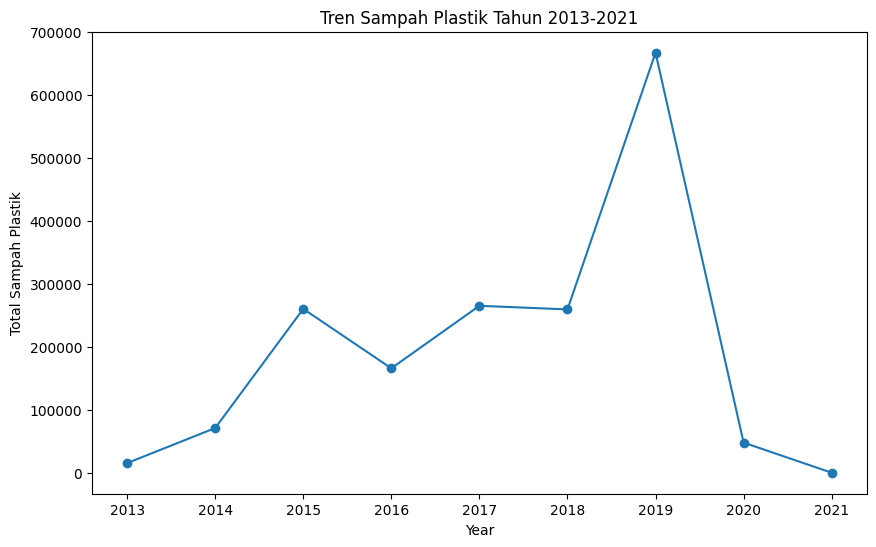

In [62]:
# 5. LINE CHART
ax = plt.figure()
plastic_per_year = (
    df_final[df_final['category'] == 'Plastic']
    .groupby(df_final['EventDate'].dt.year)['Jumlah_Sampah']
    .sum()
)
plt. figure(figsize=(10, 6))
plastic_per_year.plot(marker='o')
plt.title('Tren Sampah Plastik Tahun 2013-2021')
plt.xlabel('Year')
plt.ylabel('Total Sampah Plastik')
plt.show()

## Pertanyaan Bisnis 1
Hanya 24.2% sampah pantai yang dapat didaur ulang, sementara 75.8% sisanya tidak dapat didaur ulang, menunjukkan 3 dari 4 sampah yang ditemukan di pantai adalah dead-end waste yang tidak memiliki nilai ekonomi.

## Pertanyaan Bisnis 2
Sampah dengan karakteristik fisik *hard* (keras) memiliki recyclability rate 64.3%, hampir 7 kali lebih tinggi dibandingkan sampah dengan karakteristik fisik *flexible* yang hanya 9.7%. Sampah dengan karakteristik fisik tidak diketahui tidak dapat didaur ulang hal ini menunjukkan karakteristik fisik sangat berpengaruh terdapat peluang daur ulang.

## Pertanyaan Bisnis 3
Cigarette butts and filters mendominasi sampah non-recyclable yang ditemukan di pantai sebesar 38.8% dari total sampah non-recyclable, disusul dengan plastik yang mayoritas berukuran kecil 2.5-5 cm(15.2%), Polystyrene pieces (8.3%), Shopping Bags (6.5%), dan Crisps/Sweets wrappers (5.4%). Hampir 99% sampah yang yang ditemukan kategori plastik, selain itu ditemukan juga sampah kategori wax/paraffin (1.1%).

## Pertanyaan Bisnis 4
Sampah kategori Metal dan Glass/Ceramics adalah material dengan recyclability rate tertinggi (100%), diikuti Paper/Cardboard (85%) dan Processed Wood (67%). Sebaliknya, Plastic hanya memiliki rate 14%, sementara Rubber, Chemicals, dan Cloth/Textile termasuk kategori sampah sulit didaur ulang. Kategori Plastic memiliki volume sampah terbesar, tetapi memiliki nilai daur ulang lebih rendah karena hanya platik PET dan HDPE yang memiliki nilai ekonomi.

## Pertanyaan Bisnis 5
Volume sampah plastik di garis pantai tidak menunjukkan tren linear meningkat, melainkan berfluktuasi dengan puncak tertinggi di tahun 2019 sekitar 660.000 unit lalu turun drastis di 2020–2021. Penurunan ini kemungkinan besar disebabkan adanya pembatasan aktivitas saat pandemi COVID-19.

## Kebijakan
1. Perlunya kebijakan preventif untuk mendukung kebersihan pantai. Mayoritas sampah yang ditemukan tidak dapat didaur ulang dan memberikan nilai ekonomi. 
2. Adanya larangan penggunaan kemasan plastik sekali pakai dan menerapkan smoke free zone akan berdampak pada volume sampah non-recyclable, karena hampir 4 dari 10 sampah yang ditemukan merupakan Cigarette butts and filters. 